# Superstore sales forecasting

Exploring the Sample Superstore data and building the three-month Prophet forecast that backs the dashboard. The reusable code lives in the `forecasting` package; this notebook is the walk-through.

In [1]:
import logging
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
import warnings; warnings.simplefilter('ignore')

import matplotlib.pyplot as plt
import pandas as pd

from forecasting import config, data, features, forecast

pd.set_option('display.float_format', lambda v: f'{v:,.2f}')

df = data.load_clean()
print(df.shape)
df[[config.DATE_COL, config.REGION_COL, config.CATEGORY_COL,
    config.SUBCATEGORY_COL, config.SALES_COL, config.PROFIT_COL]].head()

(9994, 21)


,Order Date,Region,Category,Sub-Category,Sales,Profit
0,2017-11-08,South,Furniture,Bookcases,261.96,41.91
1,2017-11-08,South,Furniture,Chairs,731.94,219.58
2,2017-06-12,West,Office Supplies,Labels,14.62,6.87
3,2016-10-11,South,Furniture,Tables,957.58,-383.03
4,2016-10-11,South,Office Supplies,Storage,22.37,2.52


## The headline numbers

The KPI-card measures, computed the same way the dashboard and the Power BI report compute them.

In [2]:
k = features.kpis(df)
print(f"Total sales:      ${k['total_sales']:,.0f}")
print(f"Total profit:     ${k['total_profit']:,.0f}")
print(f"Profit margin:    {k['profit_margin']*100:.1f}%")
print(f"Orders:           {k['orders']:,}")
print(f"Avg order value:  ${k['avg_order_value']:,.0f}")
print(f"Latest YoY:        {k['yoy_pct']:+.1f}%")

Total sales:      $2,297,201
Total profit:     $286,397
Profit margin:    12.5%
Orders:           5,009
Avg order value:  $459
Latest YoY:        +20.4%


## Where the sales are

Technology and the West region lead; the monthly trend shows a clear yearly shape with a fourth-quarter ramp.

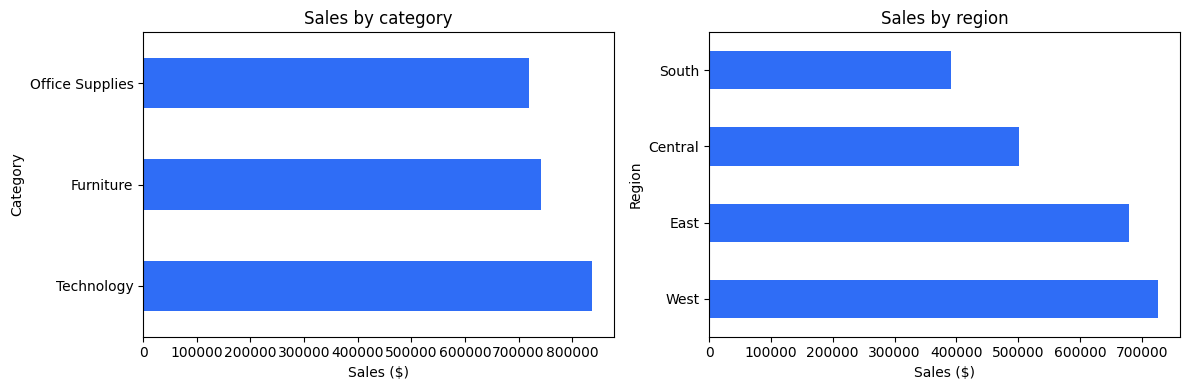

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
features.sales_by(df, config.CATEGORY_COL).plot.barh(ax=axes[0], color='#2f6df6')
axes[0].set_title('Sales by category'); axes[0].set_xlabel('Sales ($)')
features.sales_by(df, config.REGION_COL).plot.barh(ax=axes[1], color='#2f6df6')
axes[1].set_title('Sales by region'); axes[1].set_xlabel('Sales ($)')
plt.tight_layout(); plt.show()

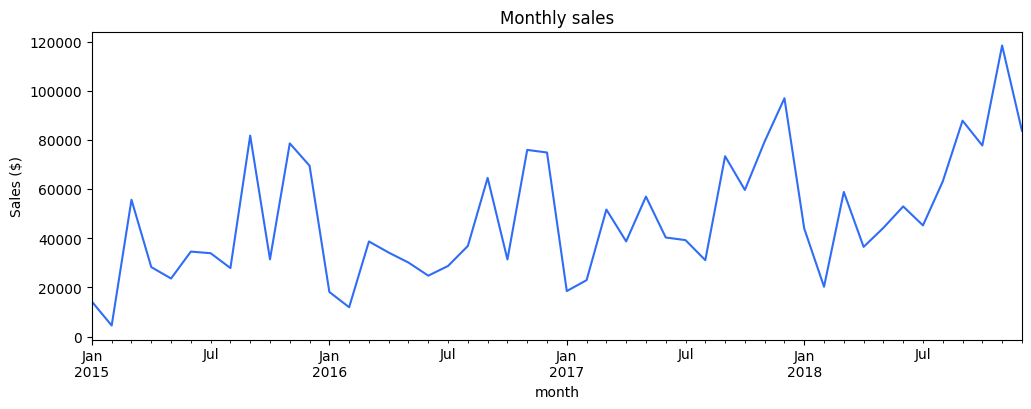

In [4]:
monthly = features.monthly_sales(df).set_index('month')['sales']
ax = monthly.plot(figsize=(12, 4), color='#2f6df6')
ax.set_title('Monthly sales'); ax.set_ylabel('Sales ($)'); plt.show()

## Year over year

The `Sales YoY %` measure as a table.

In [5]:
features.yoy_table(df)

,sales,prev_year_sales,yoy_change,yoy_pct
year,,,,
2015,"484,247.50",NaN,NaN,NaN
2016,"470,532.51","484,247.50","-13,714.99",-2.83
2017,"609,205.60","470,532.51","138,673.09",29.47
2018,"733,215.26","609,205.60","124,009.66",20.36


## The daily series

Sum orders to one figure per day and fill the no-order days with zero so Prophet sees a regular daily frequency.

In [6]:
daily = data.daily_sales(df)
print(f'{len(daily):,} days, {int((daily.sales == 0).sum())} with no orders')
prophet_df = data.to_prophet(daily)
prophet_df.tail()

1,458 days, 222 with no orders


,ds,y
1453,2018-12-26,814.59
1454,2018-12-27,177.64
1455,2018-12-28,"1,657.35"
1456,2018-12-29,"2,915.53"
1457,2018-12-30,713.79


## The Prophet model

Weekly and yearly seasonality plus US public holidays, forecasting 90 days ahead with a 90% interval.

01:55:53 - cmdstanpy - INFO - Chain [1] start processing


01:55:53 - cmdstanpy - INFO - Chain [1] done processing


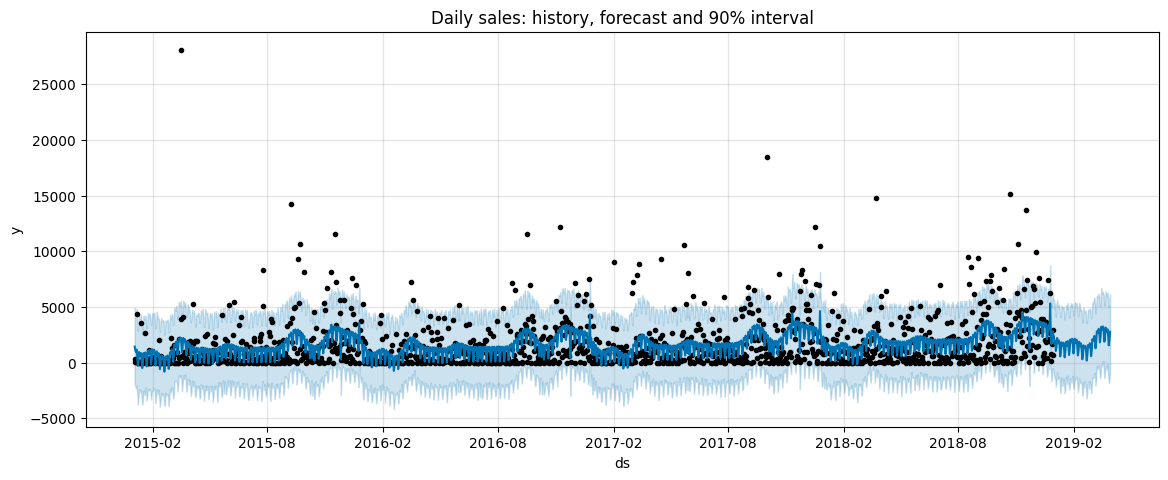

In [7]:
model, raw = forecast.fit_forecast(prophet_df)
fig = model.plot(raw)
fig.gca().set_title('Daily sales: history, forecast and 90% interval')
fig.set_size_inches(12, 4.5); plt.show()

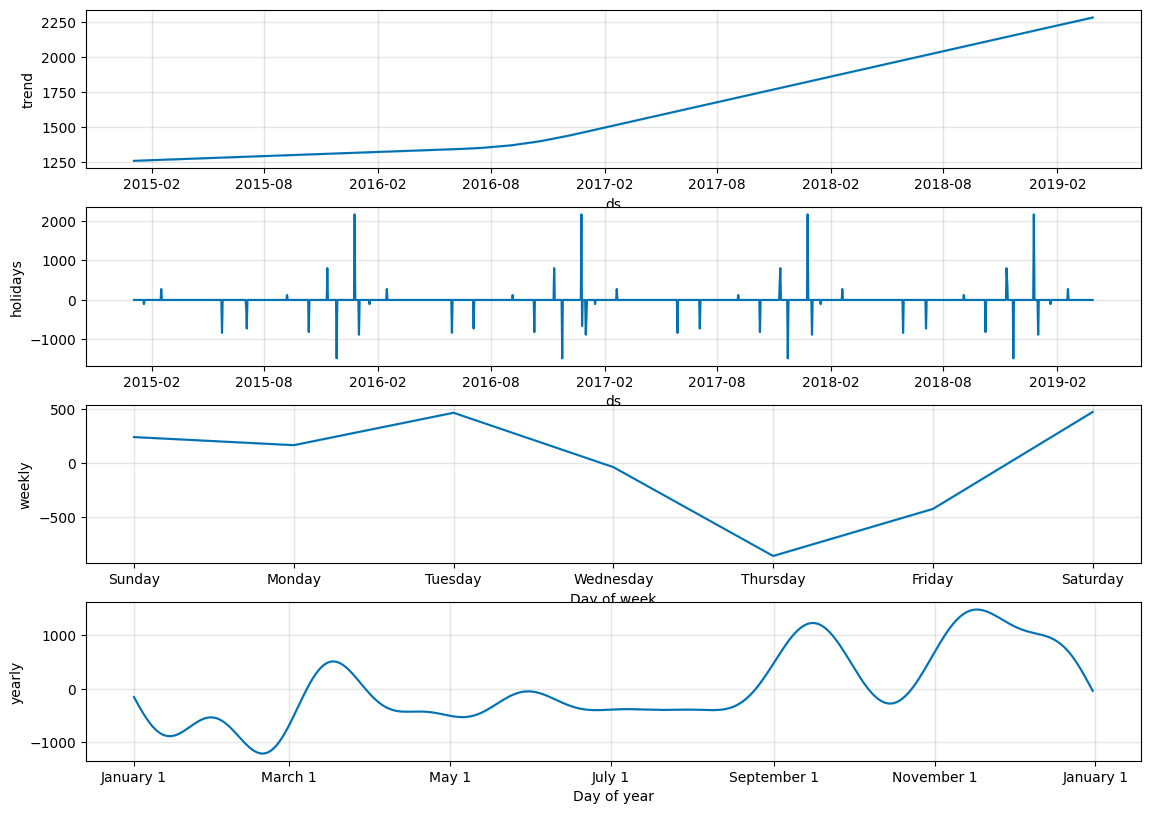

In [8]:
fig = model.plot_components(raw)
fig.set_size_inches(12, 8); plt.show()

## Does it actually work?

Hold out the last 90 days, fit on the rest, and score. The period total is what a sales forecast is judged on; the day-level error is higher because daily sales are spiky.

In [9]:
scores = forecast.backtest(prophet_df)
print(f"90-day total error:  {scores['total_error_pct']:+.1f}%")
print(f"Daily WAPE:          {scores['wape_pct']:.1f}%")
print(f"Daily MAE:           ${scores['mae']:,.0f}")
print(f"Daily RMSE:          ${scores['rmse']:,.0f}")

01:55:53 - cmdstanpy - INFO - Chain [1] start processing


01:55:53 - cmdstanpy - INFO - Chain [1] done processing


90-day total error:  -12.6%
Daily WAPE:          69.8%
Daily MAE:           $2,149
Daily RMSE:          $2,973


The training script repeats this fit for every region and category slice and writes the combined forecast to `outputs/forecast.csv`, which is what the dashboard and the Power BI report read.